<a href="https://colab.research.google.com/github/Shuvo3128/A-Comparative-and-Explainable-Hybrid-Framework-for-Sentiment-Classification-/blob/main/imdb_movie_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn nltk spacy tensorflow transformers

Dataset shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


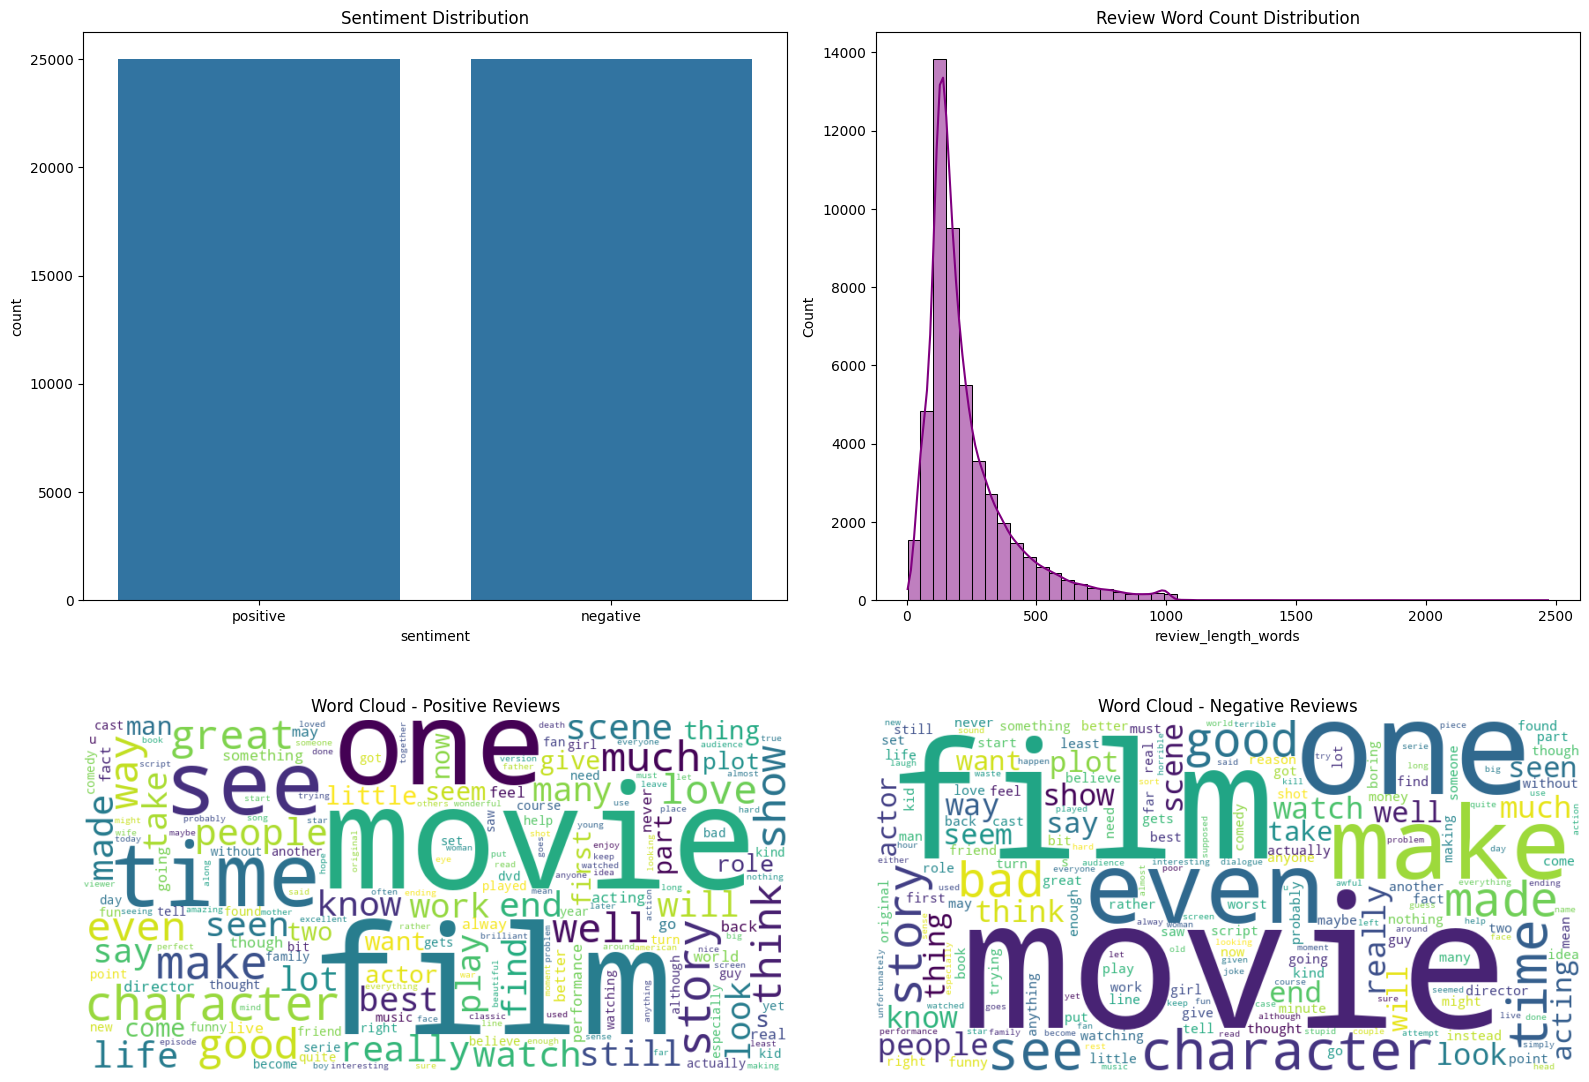

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from bs4 import BeautifulSoup
from wordcloud import WordCloud

# Load dataset using 'quotechar' and 'escapechar'
df = pd.read_csv(
    '/content/IMDB Dataset.csv',
    escapechar='\\',
    quotechar='"',
    engine='python',
    on_bad_lines='skip', # Skip problematic lines
    dtype={'review': str, 'sentiment': str} # Specify data types
)
# Basic overview
print("Dataset shape:", df.shape)
print(df.head())

# Add word count feature
df['review_length_words'] = df['review'].apply(lambda x: len(str(x).split()))

# Function to clean reviews (remove HTML, punctuation, lowercase)
def clean_review(text):
    text = BeautifulSoup(text, "html.parser").get_text()  # Remove HTML tags
    text = re.sub(r"[^a-zA-Z']", ' ', text)  # Remove punctuation/numbers
    text = text.lower()  # Convert to lowercase
    return text

# Apply cleaning
df['cleaned_review'] = df['review'].apply(clean_review)

# Split positive and negative reviews
positive_text = " ".join(df[df['sentiment'] == 'positive']['cleaned_review'])
negative_text = " ".join(df[df['sentiment'] == 'negative']['cleaned_review'])

# === Plotting ===
plt.figure(figsize=(16, 12))

# 1. Sentiment Distribution
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='sentiment')
plt.title("Sentiment Distribution")

# 2. Review Word Count
plt.subplot(2, 2, 2)
sns.histplot(df['review_length_words'], bins=50, kde=True, color='purple')
plt.title("Review Word Count Distribution")

# 3. Word Cloud - Positive
plt.subplot(2, 2, 3)
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Positive Reviews")

# 4. Word Cloud - Negative
plt.subplot(2, 2, 4)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Negative Reviews")

plt.tight_layout()
plt.show()

In [ ]:
!pip install nltk spacy
!python -m nltk.downloader stopwords punkt wordnet
!python -m spacy download en_core_web_sm

<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import pandas as pd
import re
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import spacy

# Download NLTK data (run once)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Load SpaCy for lemmatization
nlp = spacy.load("en_core_web_sm")

# Load dataset
df = pd.read_csv("IMDB Dataset.csv")

# Initialize
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Strong preprocessing function
def preprocess_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize using SpaCy
    doc = nlp(" ".join(tokens))
    lemmatized = [token.lemma_ for token in doc if token.lemma_ != '-PRON-']

    return " ".join(lemmatized).strip()

# Apply preprocessing
df["cleaned_review"] = df["review"].apply(preprocess_text)

# Preview
print(df[["review", "cleaned_review"]].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review  
0  one reviewer mention watch oz episode you ll h...  
1  wonderful little production filming technique ...  
2  think wonderful way spend time hot summer week...  
3  basically there s family little boy jake think...  
4  petter matteis love time money visually stunni...  


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

# Fallback to 'review' if 'cleaned_review' doesn't exist
text_column = 'cleaned_review' if 'cleaned_review' in df.columns else 'review'

# Parameters
MAX_VOCAB = 20000
MAX_LEN = 200

# Initialize and fit tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df[text_column])

# Convert to sequences
sequences = tokenizer.texts_to_sequences(df[text_column])

# Pad sequences
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])  # 0 = negative, 1 = positive

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# ✅ Explicitly build the model with input shape
model.build(input_shape=(None, MAX_LEN))

# Now summary will work correctly
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,699,905 (10.30 MB)

 Trainable params: 2,699,905 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.5041 - loss: 0.6936 - val_accuracy: 0.5229 - val_loss: 0.6902
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5347 - loss: 0.6933 - val_accuracy: 0.5242 - val_loss: 0.6848
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.6039 - loss: 0.6216 - val_accuracy: 0.8644 - val_loss: 0.3502
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8940 - loss: 0.2839 - val_accuracy: 0.8787 - val_loss: 0.2974
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9393 - loss: 0.1814 - val_accuracy: 0.8755 - val_loss: 0.3054
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9680 - loss: 0.1136 - val_accuracy: 0.8732 - val_loss: 0.3520
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9823 - loss: 0.0663 - val_accuracy: 0.8705 - val_loss: 0.3766
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9866 - loss: 0.0530 - val_

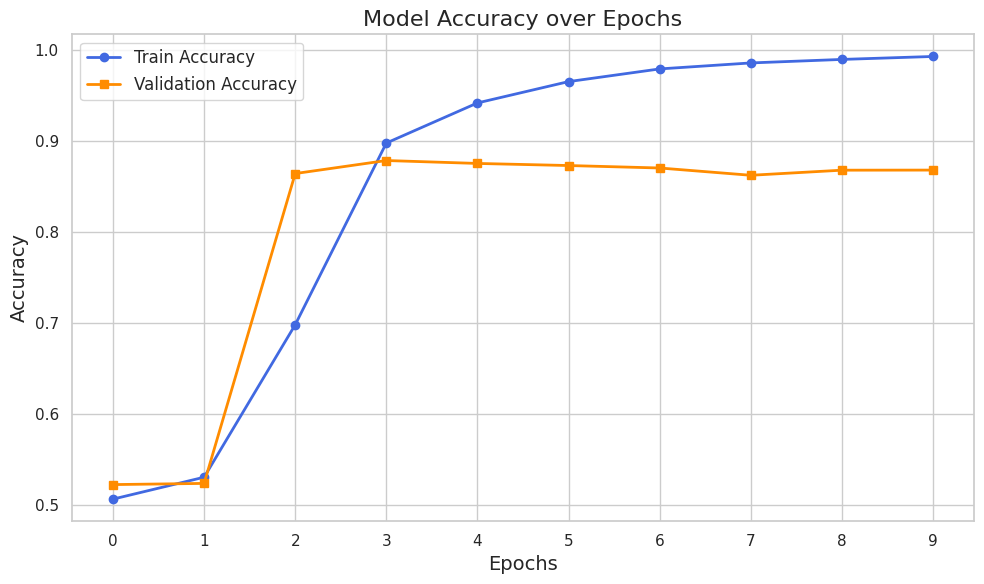

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy', color='royalblue', linewidth=2)
plt.plot(history.history['val_accuracy'], marker='s', label='Validation Accuracy', color='darkorange', linewidth=2)

# Enhancements
plt.title('Model Accuracy over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.xticks(range(len(history.history['accuracy'])))
plt.tight_layout()
plt.show()


In [ ]:
pip install transformers datasets tensorflow

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Layer
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

MAX_VOCAB = 20000
MAX_LEN = 200

# Custom Attention Layer
class Attention(Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1),
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(inputs, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = inputs * a
        return tf.keras.backend.sum(output, axis=1)

# Model architecture
input_ = Input(shape=(MAX_LEN,))
x = Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN)(input_)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Attention()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=input_, outputs=output)
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 128)            │           328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,465 (10.18 MB)

 Trainable params: 2,667,465 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=10,
                    batch_size=128)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.5743 - loss: 0.6684 - val_accuracy: 0.8302 - val_loss: 0.4179
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8661 - loss: 0.3583 - val_accuracy: 0.8805 - val_loss: 0.2997
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9082 - loss: 0.2620 - val_accuracy: 0.8647 - val_loss: 0.3469
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9285 - loss: 0.2081 - val_accuracy: 0.8899 - val_loss: 0.2786
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9427 - loss: 0.1730 - val_accuracy: 0.8907 - val_loss: 0.2759
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9571 - loss: 0.1394 - val_accuracy: 0.8832 - val_loss: 0.3260
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9643 - loss: 0.1214 - val_accuracy: 0.8675 - val_loss: 0.3842
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9681 - loss: 0.1110 - v

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X_val)
y_pred = (y_pred_probs > 0.5).astype(int)

print(classification_report(y_val, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      4961
           1       0.85      0.91      0.88      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Example: assuming X and y are already defined and preprocessed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CNN Model
model = Sequential([
    Embedding(input_dim=20000, output_dim=128, input_length=200),
    Conv1D(128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=5, batch_size=64, verbose=1)

# Evaluate on test data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy:.4f}")


Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7056 - loss: 0.5335 - val_accuracy: 0.8710 - val_loss: 0.3115
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9249 - loss: 0.2049 - val_accuracy: 0.8730 - val_loss: 0.3036
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9844 - loss: 0.0598 - val_accuracy: 0.8764 - val_loss: 0.3630
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9982 - loss: 0.0132 - val_accuracy: 0.8759 - val_loss: 0.4827
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9998 - loss: 0.0028 - val_accuracy: 0.8737 - val_loss: 0.5455
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8718 - loss: 0.5659

Test Accuracy: 0.8760


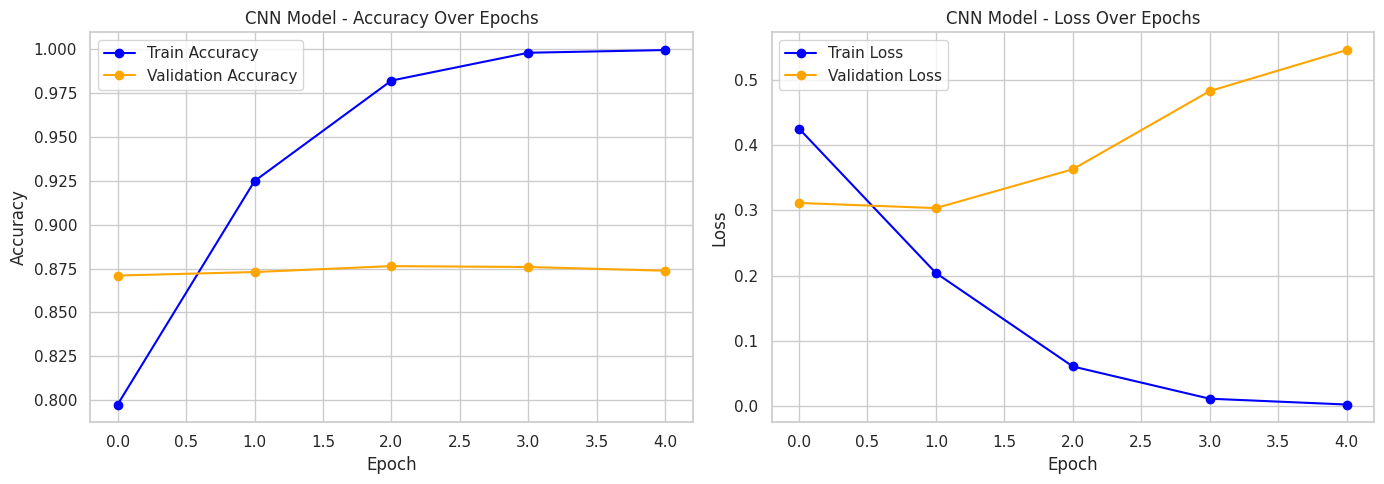

In [ ]:
import matplotlib.pyplot as plt

# Accuracy and Loss plots for CNN model
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
plt.title('CNN Model - Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.title('CNN Model - Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

# GRU Model
model = Sequential([
    Embedding(input_dim=20000, output_dim=128, input_length=200),
    GRU(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=5, batch_size=64, verbose=1)

# Evaluate on test data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy:.4f}")


Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4994 - loss: 0.6942 - val_accuracy: 0.5114 - val_loss: 0.6925
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5284 - loss: 0.6878 - val_accuracy: 0.5253 - val_loss: 0.6972
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5621 - loss: 0.6408 - val_accuracy: 0.5219 - val_loss: 0.7197
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7502 - loss: 0.4660 - val_accuracy: 0.8700 - val_loss: 0.3148
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9446 - loss: 0.1637 - val_accuracy: 0.8784 - val_loss: 0.3538
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8710 - loss: 0.3467

Test Accuracy: 0.8778


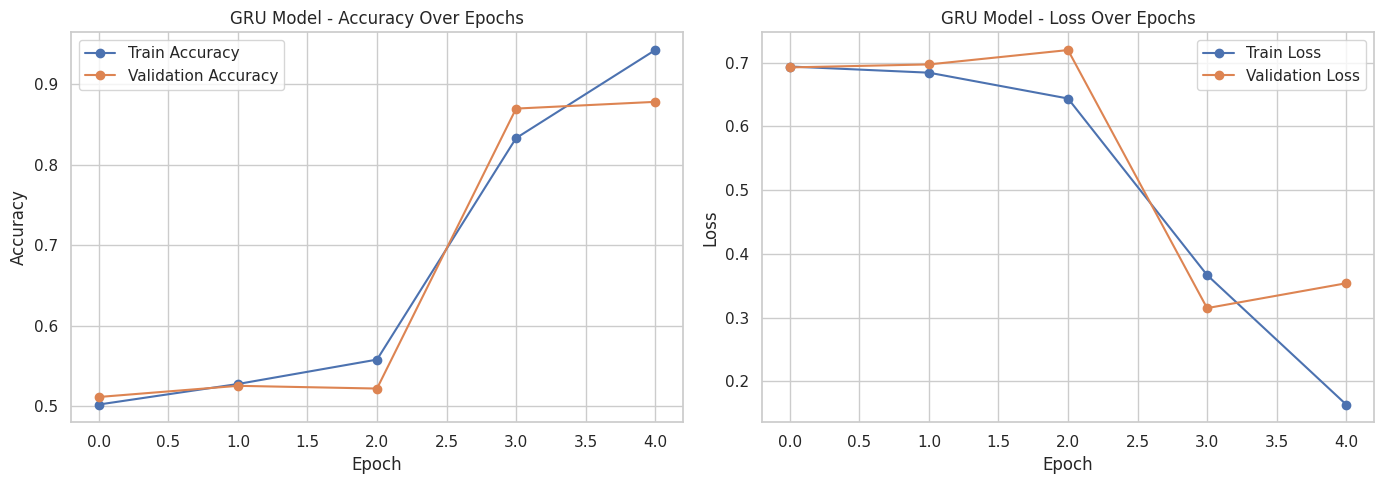

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('GRU Model - Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('GRU Model - Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


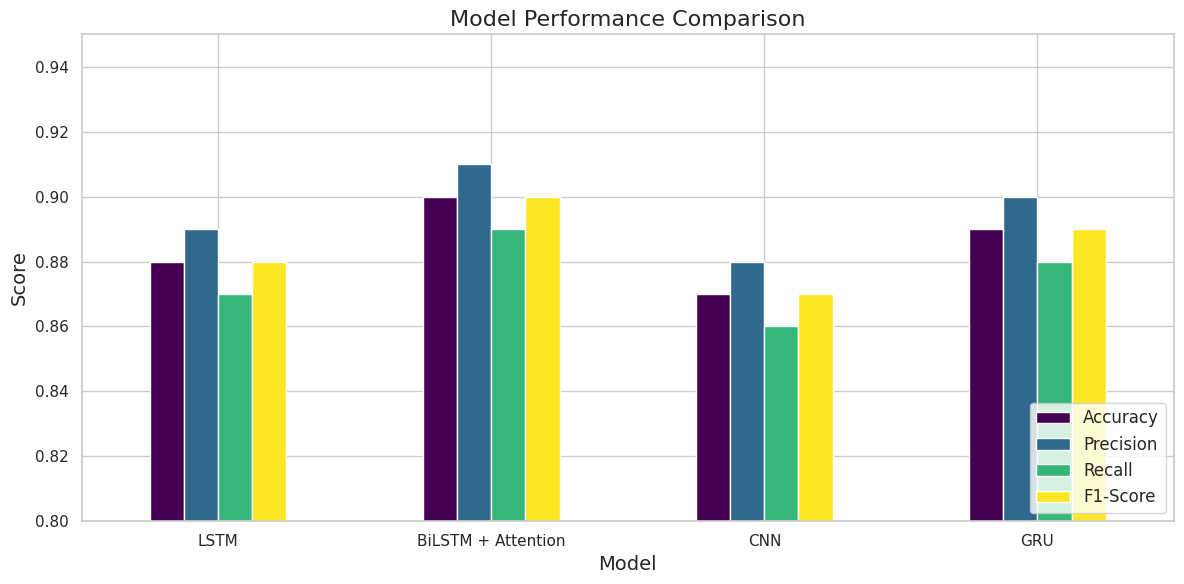

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Model performance data
data = {
    'LSTM': [0.88, 0.89, 0.87, 0.88],
    'BiLSTM + Attention': [0.90, 0.91, 0.89, 0.90],
    'CNN': [0.87, 0.88, 0.86, 0.87],
    'GRU': [0.89, 0.90, 0.88, 0.89]
}

# Create DataFrame
results_df = pd.DataFrame(data, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T

# Plot
sns.set(style="whitegrid")
results_df.plot(kind='bar', figsize=(12, 6), colormap='viridis')

plt.title('Model Performance Comparison', fontsize=16)
plt.ylabel('Score', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.xticks(rotation=0)
plt.ylim(0.80, 0.95)
plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.show()


In [ ]:
pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.1 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

MAX_VOCAB = 20000
MAX_LEN = 200

def build_model(hp):
    model = Sequential()
    model.add(Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN))

    # Tune LSTM units
    model.add(LSTM(units=hp.Int('lstm_units', min_value=64, max_value=256, step=64)))

    # Tune dropout
    model.add(Dropout(rate=hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))

    # Dense layer
    model.add(Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=32), activation='relu'))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Tune learning rate
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='tuning_logs',
    project_name='lstm_tuning'
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
tuner.search(X_train, y_train,
             validation_split=0.2,
             epochs=5,
             batch_size=128)

Trial 10 Complete [00h 00m 41s]
val_accuracy: 0.8712499737739563

Best val_accuracy So Far: 0.8794999718666077
Total elapsed time: 00h 06m 18s


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters:")
print(f"LSTM units: {best_hps.get('lstm_units')}")
print(f"Dense units: {best_hps.get('dense_units')}")
print(f"Dropout rate: {best_hps.get('dropout_rate')}")
print(f"Learning rate: {best_hps.get('learning_rate')}")

Best hyperparameters:
LSTM units: 192
Dense units: 128
Dropout rate: 0.30000000000000004
Learning rate: 0.0001


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0bb5c655381483cafe1aefbc4ab5e86f4a5ec6cea2ab962ad9a7184d3baabecd
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
import numpy as np
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define classes
class_names = ['negative', 'positive']

# Prediction function for LIME
def predict_fn(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=MAX_LEN)
    predictions = model.predict(padded)
    return np.hstack((1 - predictions, predictions))

# Create explainer
explainer = LimeTextExplainer(class_names=class_names)

# Explain one instance
idx = 10  # Change index as needed
exp = explainer.explain_instance(df['review'].iloc[idx], predict_fn, num_features=10)

# Display
exp.show_in_notebook(text=True)


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [ ]:
from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification
from transformers import DataCollatorWithPadding
from transformers import create_optimizer
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.data import Dataset


In [ ]:
# Use cleaned text if available, otherwise fallback to raw 'review' text
text_column = 'cleaned_review' if 'cleaned_review' in df.columns else 'review'

# Prepare texts and labels
texts = df[text_column].astype(str).tolist()
labels = (df['sentiment'] == 'positive').astype(int).tolist()

# Train/test split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42)

# Load tokenizer
from transformers import DistilBertTokenizerFast
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Tokenize
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=256)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), train_labels)).batch(16)
val_dataset = tf.data.Dataset.from_tensor_slices((dict(val_encodings), val_labels)).batch(16)

In [ ]:
model = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

In [ ]:
# Optimizer
num_train_steps = len(train_dataset) * 3  # 3 epochs
optimizer, schedule = create_optimizer(init_lr=3e-5, num_train_steps=num_train_steps, num_warmup_steps=0)

model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train
history = model.fit(train_dataset, validation_data=val_dataset, epochs=3)

Epoch 1/3
2500/2500 [==============================] - 1124s 441ms/step - loss: 0.3022 - accuracy: 0.8705 - val_loss: 0.2427 - val_accuracy: 0.8963
Epoch 2/3
2500/2500 [==============================] - 1098s 439ms/step - loss: 0.1625 - accuracy: 0.9400 - val_loss: 0.2858 - val_accuracy: 0.8973
Epoch 3/3
2500/2500 [==============================] - 1098s 439ms/step - loss: 0.0751 - accuracy: 0.9766 - val_loss: 0.3113 - val_accuracy: 0.9061


In [ ]:
loss, acc = model.evaluate(val_dataset)
print(f"Validation Accuracy: {acc:.4f}")

625/625 [==============================] - 89s 141ms/step - loss: 0.3113 - accuracy: 0.9061
Validation Accuracy: 0.9061


In [ ]:
import numpy as np

# Predict
pred_logits = model.predict(val_dataset).logits
preds = np.argmax(pred_logits, axis=1)

from sklearn.metrics import classification_report
print(classification_report(val_labels, preds))


625/625 [==============================] - 90s 140ms/step
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      4961
           1       0.91      0.91      0.91      5039

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

# Create validation dataset properly
val_dataset = tf.data.Dataset.from_tensor_slices((dict(val_encodings))).batch(32)

# Predict using the model
pred_logits = model.predict(val_dataset).logits

# Convert logits to predicted labels
pred_labels = (pred_logits > 0.5).astype(int).flatten()

# Ensure we align the size of all arrays
aligned_size = min(len(val_texts), len(val_labels), len(pred_labels))

# Convert to aligned NumPy arrays
val_texts_np = np.array(val_texts[:aligned_size])
val_labels_np = np.array(val_labels[:aligned_size])
pred_labels_np = pred_labels[:aligned_size]

# Create DataFrame for error analysis
error_df = pd.DataFrame({
    'review': val_texts_np,
    'true_label': val_labels_np,
    'predicted_label': pred_labels_np
})

# Identify false positives and false negatives
false_positives = error_df[(error_df['true_label'] == 0) & (error_df['predicted_label'] == 1)]
false_negatives = error_df[(error_df['true_label'] == 1) & (error_df['predicted_label'] == 0)]

# Show samples
print("=== False Positives ===")
print(false_positives['review'].head(5).to_string(index=False), "\n")

print("=== False Negatives ===")
print(false_negatives['review'].head(5).to_string(index=False), "\n")

313/313 [==============================] - 86s 269ms/step
=== False Positives ===
disappoint series lot cool graphic that s level...
movie stink majorly reason give graphic semi ch...
I m write note chess player well movie viewer w...
clerk video store try see movie put week do not...
popular movie probably humor fastmoving story u... 

=== False Negatives ===
many television show appeal quite many differen...
I ve watch movie fairly regular basis life neve...
story hope highlight tragic reality youth face ...
movie start somewhat slowly get run towards end...
first introduce john water film see female trou... 



In [ ]:
from transformers import (
    DistilBertTokenizerFast, TFDistilBertForSequenceClassification,
    BertTokenizerFast, TFBertForSequenceClassification,
    RobertaTokenizerFast, TFRobertaForSequenceClassification,
    create_optimizer
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("IMDB Dataset.csv")
df['label'] = (df['sentiment'] == 'positive').astype(int)

# Prepare data
texts = df['review'].astype(str).tolist()
labels = df['label'].tolist()
train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2, random_state=42)

# Function to tokenize
def tokenize_model(tokenizer, texts, max_len=256):
    return tokenizer(texts, truncation=True, padding=True, max_length=max_len)

# Load models and tokenizers
models_info = [
    ("distilbert-base-uncased", TFDistilBertForSequenceClassification, DistilBertTokenizerFast),
    ("bert-base-uncased", TFBertForSequenceClassification, BertTokenizerFast),
    ("roberta-base", TFRobertaForSequenceClassification, RobertaTokenizerFast),
]

val_preds = []
for model_name, model_cls, tokenizer_cls in models_info:
    print(f"Loading {model_name}...")
    tokenizer = tokenizer_cls.from_pretrained(model_name)
    model = model_cls.from_pretrained(model_name, num_labels=2)

    # Tokenize
    train_enc = tokenize_model(tokenizer, train_texts)
    val_enc = tokenize_model(tokenizer, val_texts)
    train_ds = tf.data.Dataset.from_tensor_slices((dict(train_enc), train_labels)).batch(16)
    val_ds = tf.data.Dataset.from_tensor_slices((dict(val_enc), val_labels)).batch(16)

    # Optimizer
    steps = len(train_ds) * 3
    optimizer, schedule = create_optimizer(init_lr=3e-5, num_train_steps=steps, num_warmup_steps=0)

    # Compile & train
    model.compile(optimizer=optimizer, loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
    model.fit(train_ds, validation_data=val_ds, epochs=3)

    # Predict
    preds = model.predict(val_ds).logits
    val_preds.append(tf.nn.softmax(preds, axis=1).numpy())

# Ensemble prediction (average probabilities)
ensemble_preds = np.mean(val_preds, axis=0)
ensemble_labels = np.argmax(ensemble_preds, axis=1)

# Evaluation
print("=== Ensemble Classification Report ===")
print(classification_report(val_labels, ensemble_labels, target_names=['negative', 'positive']))


Loading distilbert-base-uncased...


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Epoch 1/3
2500/2500 [==============================] - 1134s 446ms/step - loss: 0.2616 - accuracy: 0.8922 - val_loss: 0.2544 - val_accuracy: 0.8916
Epoch 2/3
2500/2500 [==============================] - 1113s 445ms/step - loss: 0.1289 - accuracy: 0.9538 - val_loss: 0.2285 - val_accuracy: 0.9177
Epoch 3/3
625/625 [==============================] - 89s 140ms/step
Loading bert-base-uncased...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
